<a href="https://colab.research.google.com/github/flgc45/pythontextanalysis/blob/Text-Analysis-In-Python-Final-Project/Final_Project_(fak2127).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Intro to Text Analysis in Python: Final Project**

**Intro and Research Question:** A nation’s central bank, as well as the monetary policy it creates and implements, play a significant role in the strength, stability, and prosperity of its economy and financial system—with consequences that often reach far beyond a country’s border. While nearly all central banks have similar missions—ensuring price stability (inflation), maximum employment, financial regulation, maintaining payment systems, and implementing monetary policy—they operate within dramatically different domestic, international, economic, and political circumstances and are impacted differently by external forces. When making decisions, central banks consider a vast body of economic research and indicators, weigh different risks and tradeoffs, and face unique challenges. Further, for the most part, central banks’ speech and output, is both highly scruntinized and closely monitored by a large array of political, economic, media, and financial actors, as well as very carefully considered, feeling similar to a code or riddle at times. This context, highly relevant to understanding and implementing economic and monetary policy, as well as the public’s focus on speeches, press releases, and other publically released and available texts, makes researching central bank statements an ideal candidate for text analysis. As such, this project will focus on the following questions: how do central banks’ statements and speeches differ? Do these differences reflect each countries' unique current challenges or economic conditions?  


*Enviornment Setup*

In [1]:
!pip -q install "numpy==2.0.2" "scipy==1.14.1" "scikit-learn>=1.4"
!pip install nltk==3.9.2

import numpy, scipy, sklearn
print("NumPy:", numpy.__version__)
print("SciPy:", scipy.__version__)
print("sklearn:", sklearn.__version__)


import nltk
nltk.download('inaugural')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

print("✅ Setup complete.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 15.8 MB/s eta 0:00:00
  Attempting uninstall: nltk
    Found existing installation: nltk 3.9.1
    Uninstalling nltk-3.9.1:
      Successfully uninstalled nltk-3.9.1
NumPy: 2.0.2
SciPy: 1.14.1
sklearn: 1.6.1


[nltk_data] Downloading package inaugural to /root/nltk_data...
[nltk_data]   Unzipping corpora/inaugural.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


✅ Setup complete.


*Importing Libraries for Data Scraping and Analysis*

Code in this section adapted from [Krisel 2025](https://github.com/rskrisel/tfidf_topic_modeling/blob/main/Intro_Text_Analysis_TFIDF_LDA_Inaugurals.ipynb)

In [2]:
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import inaugural, stopwords
from nltk import word_tokenize, FreqDist

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA, LatentDirichletAllocation

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 0)

In [3]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Google Drive Folder Creation
import os

folder_name = "policy_corpus_final_FK"
drive_path = "/content/drive/MyDrive"
corpus_dir = os.path.join(drive_path, folder_name)

os.makedirs(corpus_dir, exist_ok=True)
print(f"✅ Folder ready: {corpus_dir}")

✅ Folder ready: /content/drive/MyDrive/policy_corpus_final_FK


**Methods**: In order to investigate these research questions, I constructed a text corpus consisting of the latest monetary policy statements—from October and November 2025—made by central banks. I used the newspaper3k package to web-scrape text from relevant urls, which I input manually, beginning with the US Federal Reserve, Bank of England, European Central Bank, Reserve Bank of India, the Bank of Japan, Central Bank of Brazil, People's Bank of China, Norges Bank, Bank of Canada, Swiss National Bank, Monetary Authority of Singapore, Bank of Russia, Saudi Central Bank, Reserve Bank of Australia, Bank of Korea, South African Reserve Bank, Bank of Thailand, and Central Bank of Turkiye. Text was unable to be scraped from the Bank of Japan, Central Bank of Egypt, Bank of Mexico, and Central Bank of Brazil’s website, so the four data points were dropped from the sample. Further, the Saudi Central Bank’s statement was significantly shorter than all the other banks, did not include meaningful data, and was thus dropped as an outlier.

*Scraping Central Bank webpages through inputting the URLs of the most recent monetary policy statements, using the newspaper3k package, with code adapted from [Krisel 2025](https://github.com/rskrisel/tfidf_topic_modeling/blob/main/Intro_Text_Analysis_TFIDF_LDA_Inaugurals.ipynb)*

In [5]:
# Scrape articles and save text files
!pip install newspaper3k lxml_html_clean --quiet

from newspaper import Article
import time, os, requests
from newspaper import Article, Config

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/123.0.0.0 Safari/537.36"
    ),
    "Accept-Language": "en-US,en;q=0.9",}

cfg = Config()
cfg.browser_user_agent = HEADERS["User-Agent"]
cfg.request_timeout = 20
cfg.memoize_articles = False

def extract_with_newspaper(url: str) -> str:
    """Try Newspaper with real UA; if download() gets 403, use requests + set_html()."""
    art = Article(url, config=cfg)
    try:
        art.download()
        art.parse()
        return art.text.strip()
    except Exception:
        r = requests.get(url, headers=HEADERS, timeout=30)
        r.raise_for_status()
        art = Article(url, config=cfg)
        art.set_html(r.text)
        art.parse()
        return art.text.strip()

import pathlib
SAVE_DIR = pathlib.Path("/content/drive/MyDrive/policy_corpus_final_FK")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

def safe_filename(title: str, i: int) -> str:
    base = "".join(c for c in title if c.isalnum() or c in (" ","_")).strip().replace(" ","_")
    if not base: base = f"article_{i}"
    return f"{i:02d}_{base[:60]}.txt"

def extract_article(url: str, i: int) -> str:
    try:
        text = extract_with_newspaper(url)
        source = "newspaper3k"
    except Exception as e1:
        try:
            text = extract_with_trafilatura(url)
            source = "trafilatura"
        except Exception as e2:
            raise RuntimeError(f"Both extractors failed.\nNewspaper err: {e1}\nTrafilatura err: {e2}")
    return text, source

def save_article(urls):
    import datetime
    for i, url in enumerate(urls, start=1):
        try:
            text, source = extract_article(url, i)
            title_hint = url.split("/")[-2] if "/" in url else "article"
            fname = safe_filename(title_hint, i)
            fpath = SAVE_DIR / fname
            with open(fpath, "w", encoding="utf-8") as f:
                f.write(f"URL: {url}\n")
                f.write(f"SourceExtractor: {source}\n")
                f.write(f"SavedAtUTC: {datetime.datetime.utcnow().isoformat()}Z\n\n")
                f.write(text)
            print(f"✅ Saved ({source}): {fname}")
            time.sleep(1.0)
        except Exception as e:
            print(f"⚠️ Skipped {url}: {e}")

urls = [
  "https://www.federalreserve.gov/newsevents/pressreleases/monetary20251029a.htm",
    "https://www.bankofengland.co.uk/monetary-policy-summary-and-minutes/2025/november-2025",
    "https://www.ecb.europa.eu/press/pr/date/2025/html/ecb.mp251030~cf0540b5c0.en.html",
  "https://rbi.org.in/Scripts/BS_PressReleaseDisplay.aspx?prid=61332",
  "http://www.pbc.gov.cn/en/3688229/3688311/3688329/5858781/index.html",
  "https://www.norges-bank.no/en/topics/monetary-policy/Monetary-policy-meetings/2025/november-2025/?tabs=154138",
  "https://www.snb.ch/en/publications/communication/press-releases-restricted/pre_20250925",
  "https://www.bankofcanada.ca/2025/10/fad-press-release-2025-10-29/",
  "https://www.mas.gov.sg/news/monetary-policy-statements/2025/mas-monetary-policy-statement-14oct25",
  "https://www.cbr.ru/eng/press/pr/?file=24102025_133000key_e.htm",
  "https://www.rba.gov.au/media-releases/2025/mr-25-31.html",
  "https://www.bok.or.kr/eng/bbs/E0000627/view.do?nttId=10094133&searchCnd=1&searchKwd=&depth2=400417&depth3=400022&depth=400022&pageUnit=10&pageIndex=1&programType=newsDataEng&menuNo=400022&oldMenuNo=400022",
  "https://www.resbank.co.za/en/home/publications/publication-detail-pages/statements/monetary-policy-statements/2025/november",
  "https://www.bot.or.th/en/news-and-media/news/mpc/news-20251008-3qxFSVaX.html",
  "https://www.tcmb.gov.tr/wps/wcm/connect/en/tcmb+en/main+menu/announcements/press+releases/2025/ano2025-55"

]
save_article(urls)
print("Folder:", SAVE_DIR)


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 60.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.1/211.1 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 7.9 MB/s eta 0:00:00


/tmp/ipython-input-527026238.py:68: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  f.write(f"SavedAtUTC: {datetime.datetime.utcnow().isoformat()}Z\n\n")


✅ Saved (newspaper3k): 01_pressreleases.txt
✅ Saved (newspaper3k): 02_2025.txt
✅ Saved (newspaper3k): 03_html.txt
✅ Saved (newspaper3k): 04_Scripts.txt
✅ Saved (newspaper3k): 05_5858781.txt
✅ Saved (newspaper3k): 06_november2025.txt
✅ Saved (newspaper3k): 07_pressreleasesrestricted.txt
✅ Saved (newspaper3k): 08_fadpressrelease20251029.txt
✅ Saved (newspaper3k): 09_2025.txt
✅ Saved (newspaper3k): 10_pr.txt
✅ Saved (newspaper3k): 11_2025.txt
✅ Saved (newspaper3k): 12_E0000627.txt
✅ Saved (newspaper3k): 13_2025.txt
✅ Saved (newspaper3k): 14_mpc.txt
✅ Saved (newspaper3k): 15_2025.txt
Folder: /content/drive/MyDrive/policy_corpus_final_FK


*Checking that the webscraped text files are saved in the appropriate Google Drive folder*

In [6]:
import glob

files = sorted(glob.glob(os.path.join(corpus_dir, "*.txt")))
print(f"Found {len(files)} text files in Drive.")
for f in files:
    print("-", os.path.basename(f))

Found 15 text files in Drive.
- 01_pressreleases.txt
- 02_2025.txt
- 03_html.txt
- 04_Scripts.txt
- 05_5858781.txt
- 06_november2025.txt
- 07_pressreleasesrestricted.txt
- 08_fadpressrelease20251029.txt
- 09_2025.txt
- 10_pr.txt
- 11_2025.txt
- 12_E0000627.txt
- 13_2025.txt
- 14_mpc.txt
- 15_2025.txt


*Creating a dataframe with the scraped text corpus from the central bank website URLs, using ntlk code adapted from [Krisel 2025](https://github.com/rskrisel/tfidf_topic_modeling/blob/main/Intro_Text_Analysis_TFIDF_LDA_Inaugurals.ipynb)*

In [39]:
from nltk.corpus import PlaintextCorpusReader
import pandas as pd
corpus = PlaintextCorpusReader(corpus_dir,files)

records = []
for fid in files:
  raw = corpus.raw(fid)
  records.append({'fileid':fid, 'text':raw})

df= pd.DataFrame(records).reset_index(drop=True)

#label bank names
central_bank = ['Federal Reserve', 'Bank of England', 'European Central Bank', 'Reserve Bank of India', 'Peoples Bank of China', 'Norges Bank','Swiss National Bank', "Bank of Canada","Singapore Monetary Authority", "Bank of Russia", "Reserve Bank of Australia","Bank of Korea", "South African Reserve Bank", "Bank of Thailand", "Central Bank of Turkiye"]
df['central_bank'] = central_bank

df = df.drop('fileid',axis=1)

df

text  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

**Methods**: Once scraped, the text was cleaned, streamlined, and assembled into a text corpus through the nltk package; text was made lowercase and tokenized, numbers, punctuation, and other non alphabetic characters were removed, and stopwords were deleted. In addition to the default list of English stopwords, I created a list of custom stopwards that were unlikely to yield unique insight, which I added to throughout the research process / after viewing summary statistics. I also corrected for common linguistical differences that might skew results by changing all instances of “labor” to “labour”.

*Cleaning the data in order to remove auxillary words that are not meaningful for the purposes of this analysis, with code adapted from [Krisel 2025](https://github.com/rskrisel/tfidf_topic_modeling/blob/main/Intro_Text_Analysis_TFIDF_LDA_Inaugurals.ipynb)*

In [13]:
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')

EN_STOP = set(stopwords.words('english'))
print("English stopwords:", EN_STOP)

#create custom list of stopwords
CUSTOM_STOP = {
    'url', 'https', 'sourceextractor', 'savedatutc','today','term','high','slightly', 'upward','low','come','size','ensure','new','close','create','reviewed','decisions','case','despite','headline','assessments','real','judges','place','current','according','terms','near','even','monitor','make','meanwhile','half','effect','private','issued','impede','appropriate','decided','less','more','scenario','higher','time','outlook','still','range','data','per','effects','exchange','conditions','stance','developments','development', 'cent','next','preferred','voting','chair','preferred','action','incoming','forecast','rates','projected','however','underlying','percent','quarter','key','relatively','relative','little','since','somewhat','council','governing','points','point','lower','back','board','report','would','federal', 'due', 'last', 'bank', 'mpc','may','keep', 'could', 'around', 'likely', 'also', 'first','box', 'table', 'year', 'remain', 'remains', 'policy', 'meeting', 'recent', 'economy','economic','committee', 'rate','target','members','member', 'market','continue','september'
}

#combine existing english stopwords with custom list
STOPWORDS = EN_STOP.union(CUSTOM_STOP)

def simple_clean_tokens(text):
    """
    1) Lowercase
    2) Tokenize
    3) Keep alphabetic tokens of length >= 3
    4) Remove stopwords
    """
    text = text.lower()
    tokens = word_tokenize(text)
    clean = [tok for tok in tokens if tok.isalpha() and len(tok) >= 3 and tok not in STOPWORDS]
    return clean

#linguistic differences
df['text'] = df['text'].str.replace('labor','labour')

df['tokens'] = df['text'].apply(simple_clean_tokens)
df['text_clean'] = df['tokens'].apply(lambda toks: " ".join(toks))

print("Sample tokens:", df.loc[0, 'tokens'][:25])
df[['text','central_bank','text_clean']].head(1)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


English stopwords: {'should', 'same', "we'll", 'weren', 'who', 'myself', 'against', 'd', 'mustn', "we've", "needn't", "aren't", "hasn't", "should've", 'where', "haven't", 'am', 'a', "i've", 'haven', 'than', 'do', 'with', 'whom', 'them', 'most', 'mightn', "she's", 'some', "don't", 'as', 'it', 'from', 'into', 'which', "he'd", 'y', 'that', 'and', 'an', 'll', 'ma', "mightn't", 'out', 'but', 'all', "i'd", "she'll", 'himself', "won't", 'each', 'wasn', 'o', 'i', 'was', 'our', 'doing', 'yours', "shan't", 'while', 'him', 's', "it'll", 'of', 'or', 'won', "it's", 'until', 'its', 'me', 'themselves', "we're", 'over', 'ourselves', 't', 'then', 'doesn', "they're", 'down', "you'll", 'how', 'hadn', "you're", 'your', 'if', "he's", 'ours', 'again', "doesn't", 'the', 'so', 'during', 'those', "weren't", 'here', 'their', 'we', 're', 'you', "you've", 'after', 'because', 'further', "he'll", 'has', 'hers', 'before', "you'd", 'other', 'through', 'herself', "wouldn't", 'only', 'to', 'hasn', 'there', 'don', "they

,text,central_bank,text_clean
0,"URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20251029a.htm\nSourceExtractor: newspaper3k\nSavedAtUTC: 2025-12-07T16:57:19.640033Z\n\nAvailable indicators suggest that economic activity has been expanding at a moderate pace. Job gains have slowed this year, and the unemployment rate has edged up but remained low through August; more recent indicators are consistent with these developments. Inflation has moved up since earlier in the year and remains somewhat elevated.\n\nThe Committee seeks to achieve maximum employment and inflation at the rate of 2 percent over the longer run. Uncertainty about the economic outlook remains elevated. The Committee is attentive to the risks to both sides of its dual mandate and judges that downside risks to employment rose in recent months.\n\nIn support of its goals and in light of the shift in the balance of risks, the Committee decided to lower the target range for the federal funds rate by 1/4 percentage point to 3-3/4 to 4 percent. In considering additional adjustments to the target range for the federal funds rate, the Committee will carefully assess incoming data, the evolving outlook, and the balance of risks. The Committee decided to conclude the reduction of its aggregate securities holdings on December 1. The Committee is strongly committed to supporting maximum employment and returning inflation to its 2 percent objective.\n\nIn assessing the appropriate stance of monetary policy, the Committee will continue to monitor the implications of incoming information for the economic outlook. The Committee would be prepared to adjust the stance of monetary policy as appropriate if risks emerge that could impede the attainment of the Committee's goals. The Committee's assessments will take into account a wide range of information, including readings on labour market conditions, inflation pressures and inflation expectations, and financial and international developments.\n\nVoting for the monetary policy action were Jerome H. Powell, Chair; John C. Williams, Vice Chair; Michael S. Barr; Michelle W. Bowman; Susan M. Collins; Lisa D. Cook; Austan D. Goolsbee; Philip N. Jefferson; Alberto G. Musalem; and Christopher J. Waller. Voting against this action were Stephen I. Miran, who preferred to lower the target range for the federal funds rate by 1/2 percentage point at this meeting, and Jeffrey R. Schmid, who preferred no change to the target range for the federal funds rate at this meeting.\n\nFor media inquiries, please email [email protected] or call 202-452-2955.\n\nImplementation Note issued October 29, 2025",Federal Reserve,available indicators suggest activity expanding moderate pace job gains slowed unemployment edged remained august indicators consistent inflation moved earlier elevated seeks achieve maximum employment inflation longer run uncertainty elevated attentive risks sides dual mandate downside risks employment rose months support goals light shift balance risks funds percentage considering additional adjustments funds carefully assess evolving balance risks conclude reduction aggregate securities holdings december strongly committed supporting maximum employment returning inflation objective assessing monetary implications information prepared adjust monetary risks emerge attainment goals take account wide information including readings labour inflation pressures inflation expectations financial international monetary jerome powell john williams vice michael barr michelle bowman susan collins lisa cook austan goolsbee philip jefferson alberto musalem christopher waller stephen miran funds percentage jeffrey schmid change funds media inquiries please email email protected call implementation note october


*Descriptive Statistics: Length of Central Bank Monetary Policy Statements*

As previously mentioned, the descriptive statistics revealed that the Saudi Central Bank monetary policy statement was too short to yield insights, so it was dropped as an outlier. Further, it is clear that the BOE has the longest statement, while the Fed, ECB, and Central Bank of Turkiye have much shorter statements.

Code adapted from [Krisel 2025](https://github.com/rskrisel/tfidf_topic_modeling/blob/main/Intro_Text_Analysis_TFIDF_LDA_Inaugurals.ipynb)

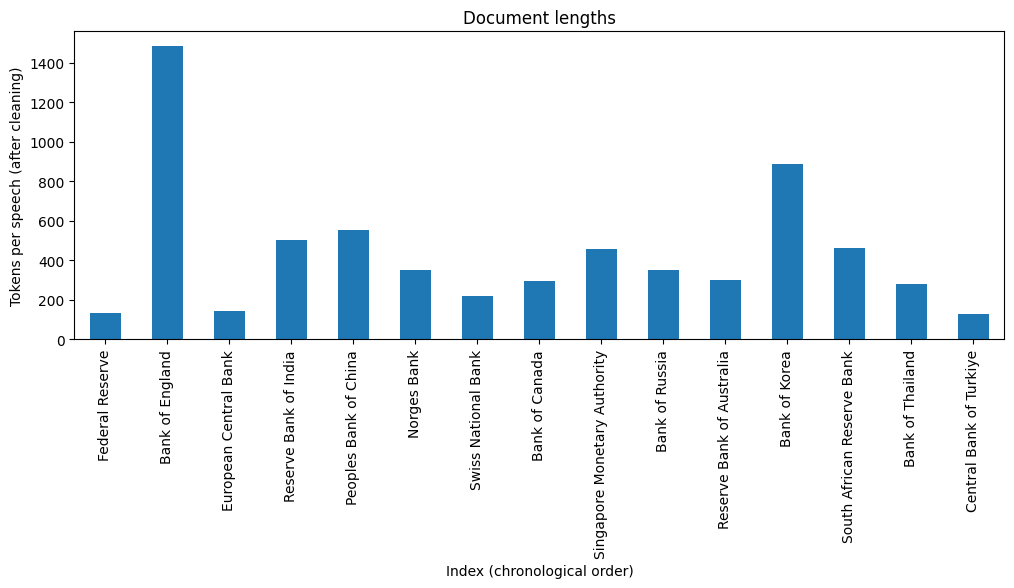

In [9]:
df['n_tokens'] = df['tokens'].apply(len)
ax = df.plot(x='central_bank', y='n_tokens', kind='bar', figsize=(12,4), legend=False)
ax.set_ylabel("Tokens per speech (after cleaning)")
ax.set_xlabel("Index (chronological order)")
ax.set_title("Document lengths")
plt.show()

*Summary Statistics: most frequently used words across all speeches.*

This exercise allowed me to iteratively refine the custom stopwords list, as it revealed which words were commonly occuring but resulted in no meaningful insight. We can see that the resulting most frequently used words include a number of the top concerns of central banks, such as inflation, growth, prices, labor, and stability. While this is an interesting result, it, of course, does not provide much of the surronding context present; for example, although we know that "price" or "prices" is often mentioned, it is not clear in what context it is mentioned (ie prices are stable, high, low, unstable, etc).

Code adapted from [Krisel 2025](https://github.com/rskrisel/tfidf_topic_modeling/blob/main/Intro_Text_Analysis_TFIDF_LDA_Inaugurals.ipynb)

In [10]:
all_tokens = [t for toks in df['tokens'] for t in toks]
fdist = FreqDist(all_tokens)

# displaying 20 most commonly used words across all central bank speeches
top_20_words = fdist.most_common(20)
words = [word for word, freq in top_20_words]
frequencies = [freq for word, freq in top_20_words]

print("Top 20 most frequent words across all speeches:\n")
for word, freq in fdist.most_common(20):
    print(f"{word:15s} {freq}")

Top 20 most frequent words across all speeches:

inflation       246
growth          131
monetary        117
risks           59
financial       55
expected        47
global          46
prices          45
demand          44
price           43
labour          40
domestic        39
trade           37
expectations    35
disinflation    24
stability       24
services        23
activity        22
core            21
uncertainty     20


Next, I created a bar chart to visualize the top 20 most frequently used words across all speeches, with some code adapted from Stack Overflow [[1](https://stackoverflow.com/questions/43214978/how-to-display-custom-values-on-a-bar-plot), [2](https://stackoverflow.com/questions/38830250/how-to-fill-matplotlib-bars-with-a-gradient), [3](https://stackoverflow.com/questions/67409261/histogram-with-seaborn) ] and [Krisel 2025](https://github.com/rskrisel/tfidf_topic_modeling/blob/main/Intro_Text_Analysis_TFIDF_LDA_Inaugurals.ipynb)

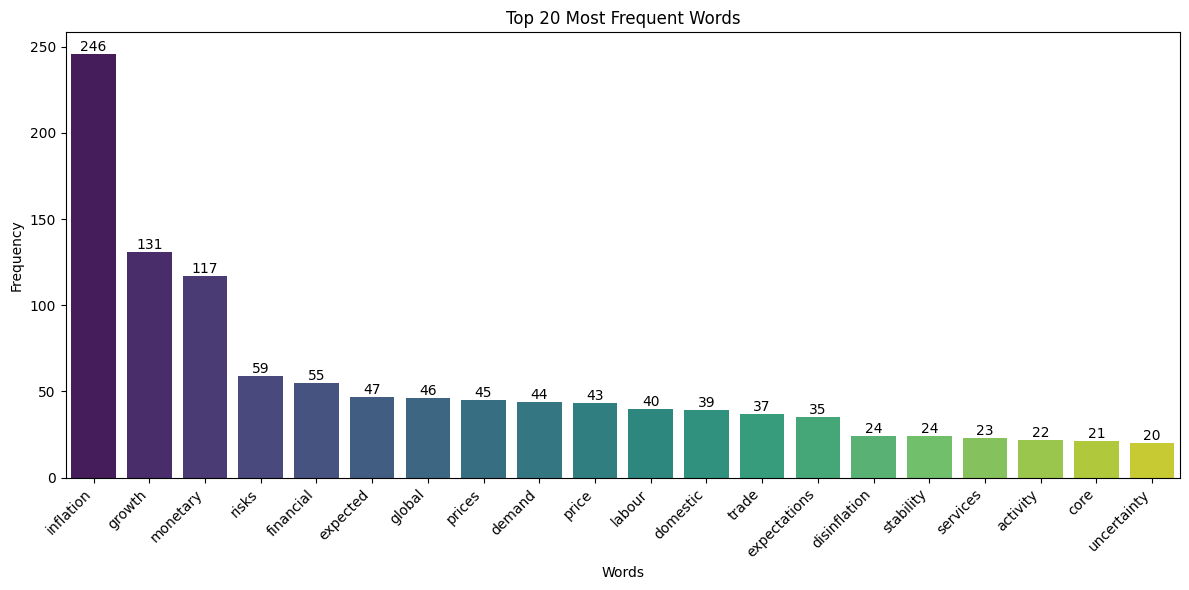

In [11]:
# Create the bar chart
plt.figure(figsize=(12, 6))
freq_20 = sns.barplot(x = words, y = frequencies, palette='viridis', hue = words, legend=False)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 20 Most Frequent Words')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
for container in freq_20.containers:
  plt.bar_label(container)
plt.show()

Term Frequency-Inverse Document Frequency (TF-IDF) analysis highlights terms that are frequent and specific to a given text, giving less weight to terms that occur commonly throughout the corpus. I used this analysis to explore which words were specific to a particular central banks' monetary policy statement, resulting in the top 12 distinctive words for each bank as the output. I also further refined the custom stopwords list when the results displayed words that were not meaningful or relevant to the research question.

Code adapted from [Krisel 2025](https://github.com/rskrisel/tfidf_topic_modeling/blob/main/Intro_Text_Analysis_TFIDF_LDA_Inaugurals.ipynb) and [Stack Overflow](https://stackoverflow.com/questions/16476924/how-can-i-iterate-over-rows-in-a-pandas-dataframe)

In [14]:
tfidf = TfidfVectorizer(min_df=2)
X_tfidf = tfidf.fit_transform(df['text_clean'])
terms = np.array(tfidf.get_feature_names_out())

def top_tfidf_terms_for_doc(doc_idx, top_n=12):
    row = X_tfidf.getrow(doc_idx).toarray().ravel()
    top_idx = row.argsort()[::-1][:top_n]
    return list(zip(terms[top_idx], row[top_idx]))

# Displays top 12 TF-IDF terms per central bank speech
for i, row in df.iterrows():
    print(f"\n=== {df.loc[i, 'central_bank']} ===")
    for term, score in top_tfidf_terms_for_doc(i, top_n=12):
        print(f"{term:15s} {score:.3f}")


=== Federal Reserve ===
funds           0.430
risks           0.255
inflation       0.225
employment      0.213
percentage      0.179
information     0.165
balance         0.153
indicators      0.142
monetary        0.135
elevated        0.133
expanding       0.121
attentive       0.121

=== Bank of England ===
inflation       0.451
disinflation    0.251
risks           0.212
evidence        0.207
upside          0.200
monetary        0.187
labour          0.172
restrictive     0.139
structural      0.127
wage            0.125
projection      0.125
risk            0.118

=== European Central Bank ===
transmission    0.323
interest        0.280
inflation       0.244
facility        0.194
mandate         0.194
unchanged       0.193
particular      0.176
monetary        0.163
medium          0.161
assessment      0.149
dynamics        0.149
considerations  0.109

=== Reserve Bank of India ===
inflation       0.324
growth          0.309
benign          0.182
demand          0.164
robust  

Comparing the similarity of the language used in central bank speeches. For each central bank, its closest 5 peers in terms of lexical similarity are displayed, regardless of length, with cosine similarity code adapted from [Stack Overflow](https://stackoverflow.com/questions/16476924/how-can-i-iterate-over-rows-in-a-pandas-dataframe) and [Krisel 2025](https://github.com/rskrisel/tfidf_topic_modeling/blob/main/Intro_Text_Analysis_TFIDF_LDA_Inaugurals.ipynb)

In [15]:
for i, row in df. iterrows():
  sim = cosine_similarity(X_tfidf)
  target = i # Chooses the most recent speech (the last row in your DataFrame) as the target document.
  pairs = [(i, sim[target, i]) for i in range(len(df)) if i != target]
  pairs_sorted = sorted(pairs, key=lambda x: x[1], reverse=True)[:5]


  print(f"\n =========== \n Most similar to {df.loc[target,'central_bank']}:")
  for idx, score in pairs_sorted: #Iterates over the top-5 most similar speeches
    print(f" {df.loc[idx,'central_bank']} (cosine={score:.3f})")



 Most similar to Federal Reserve:
 Bank of England (cosine=0.302)
 Norges Bank (cosine=0.274)
 Reserve Bank of Australia (cosine=0.265)
 South African Reserve Bank (cosine=0.212)
 Reserve Bank of India (cosine=0.212)

 Most similar to Bank of England:
 Reserve Bank of Australia (cosine=0.456)
 South African Reserve Bank (cosine=0.450)
 Norges Bank (cosine=0.438)
 Bank of Russia (cosine=0.389)
 Reserve Bank of India (cosine=0.388)

 Most similar to European Central Bank:
 Norges Bank (cosine=0.244)
 South African Reserve Bank (cosine=0.243)
 Bank of England (cosine=0.241)
 Swiss National Bank (cosine=0.227)
 Central Bank of Turkiye (cosine=0.220)

 Most similar to Reserve Bank of India:
 Singapore Monetary Authority (cosine=0.468)
 Bank of Korea (cosine=0.411)
 South African Reserve Bank (cosine=0.409)
 Bank of Canada (cosine=0.397)
 Reserve Bank of Australia (cosine=0.391)

 Most similar to Peoples Bank of China:
 Bank of Korea (cosine=0.336)
 Reserve Bank of India (cosine=0.264)
 Ban

Creating an abstract graphical representation of lexical similarity, with code adapted from [Stack Overflow](https://stackoverflow.com/questions/16476924/how-can-i-iterate-over-rows-in-a-pandas-dataframe) and [Krisel 2025](https://github.com/rskrisel/tfidf_topic_modeling/blob/main/Intro_Text_Analysis_TFIDF_LDA_Inaugurals.ipynb). While it is difficult to interpret the graph in terms of the axis, central bank statements that are clustered together may be more similar in terms of vocabulary than those located further away, who may have different patterns of word usage. As such, the Reserve Bank of Australia, South African Reserve Bank, Norges Bank, and Bank of Russia may share linguistic similarities, as might the Bank of Canada, Singapore Monetary Authority, Swiss National Bank, and Reserve Bank of India.

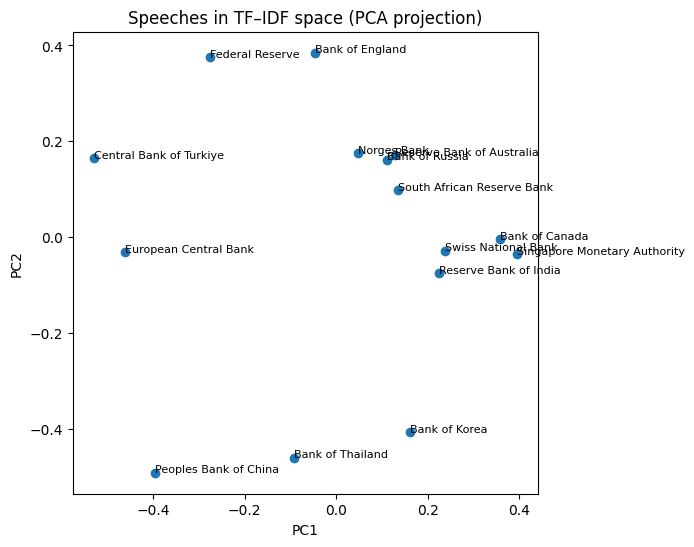

In [16]:
#graphical representation of lexical similarity

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_tfidf.toarray())
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(coords[:,0], coords[:,1])
for i, row in df.iterrows():
    ax.annotate(str(row['central_bank']), (coords[i,0], coords[i,1]), fontsize=8)
ax.set_title("Speeches in TF–IDF space (PCA projection)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.show()


Creating word clouds, which show the top TF-IDF words in each central bank's monetary policy speech, using the Word Cloud package. Words with higher TF-IDF scores are shown in larger font, while less central words are shown in smaller font. By viewing the most distinct, frequently used in each central bank speech, insight into the unique concerns of a central bank's policymakers may be possible.

Code was adapted from [Krisel 2025](https://github.com/rskrisel/tfidf_topic_modeling/blob/main/Intro_Text_Analysis_TFIDF_LDA_Inaugurals.ipynb)

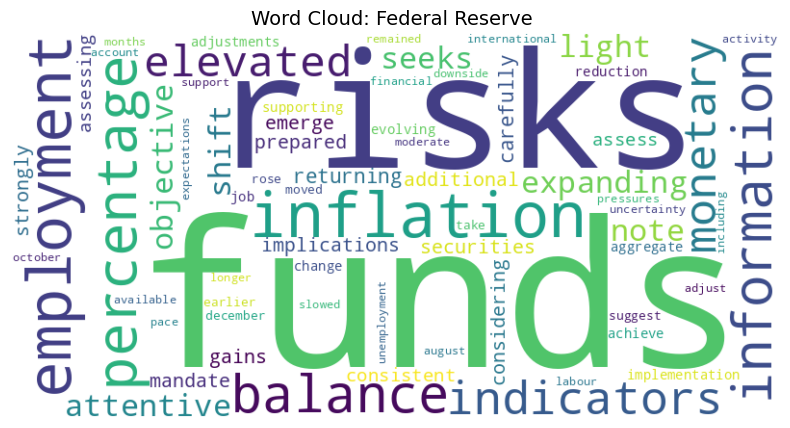

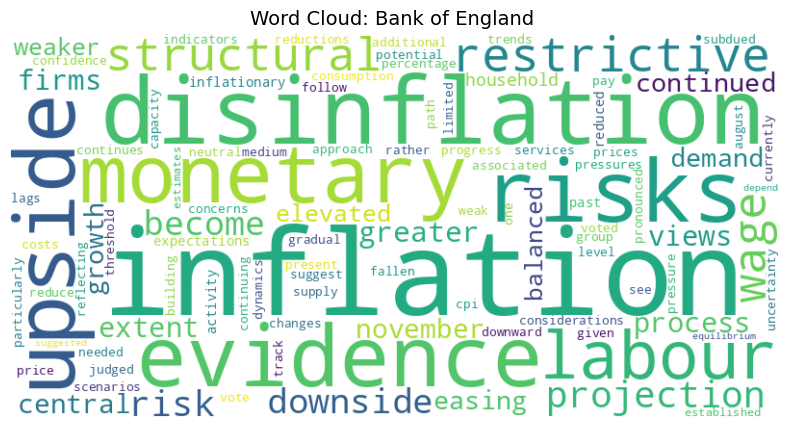

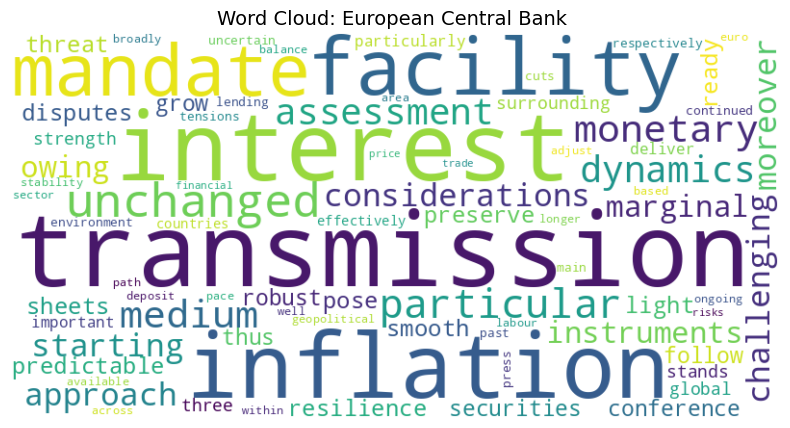

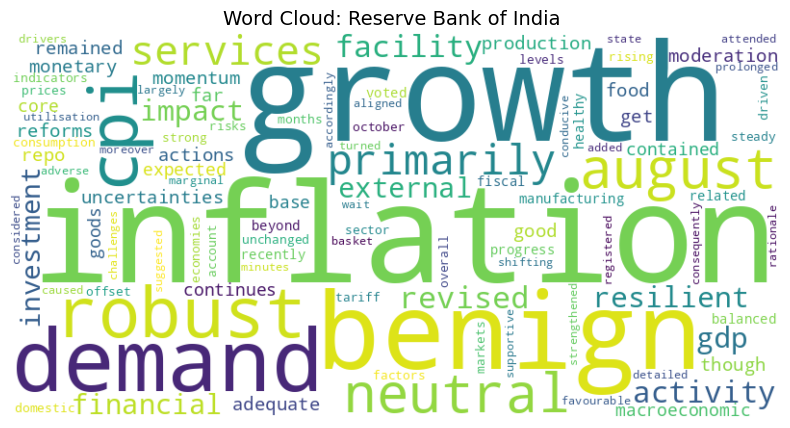

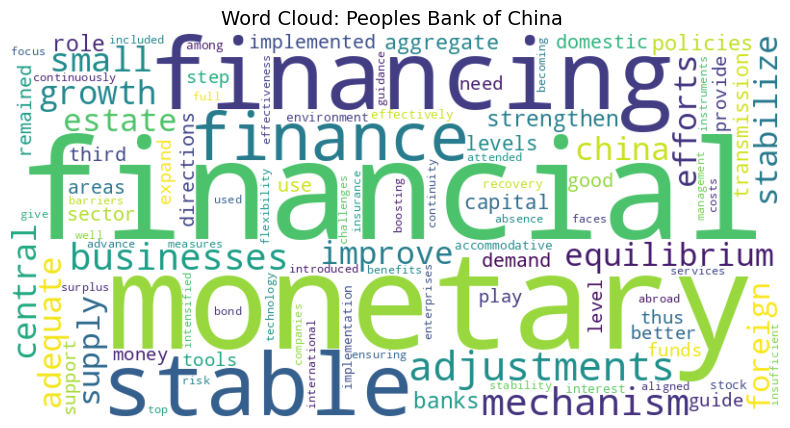

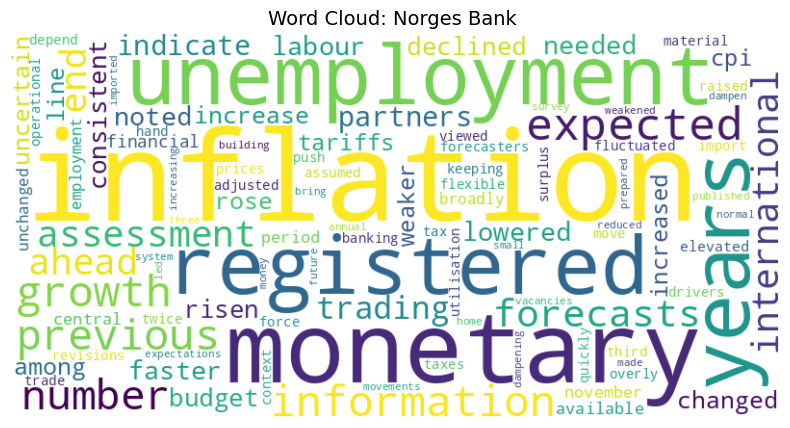

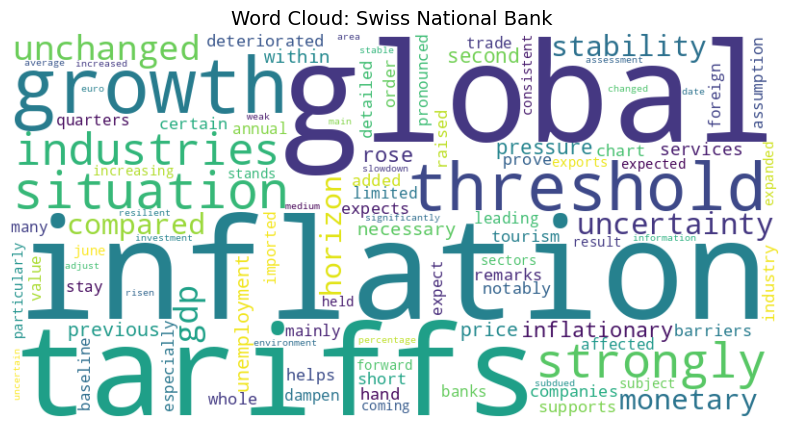

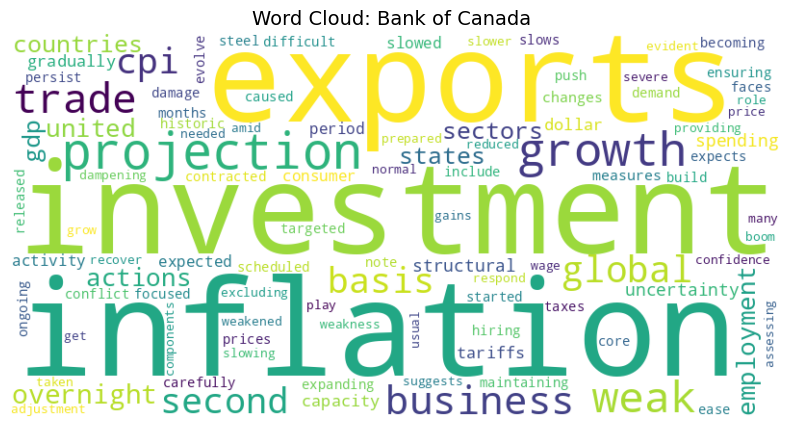

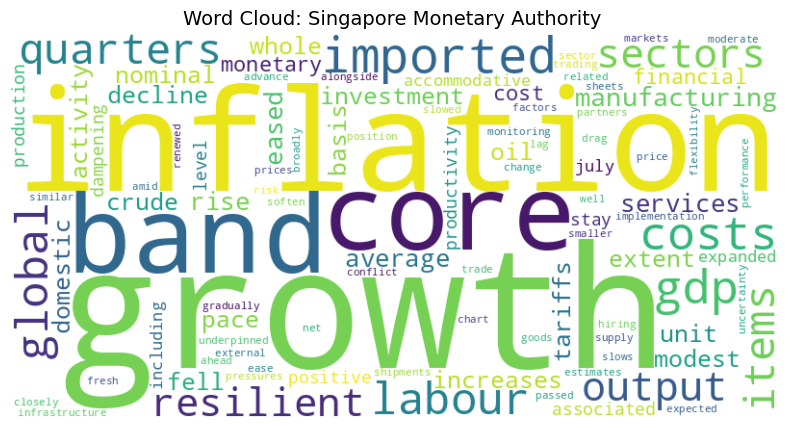

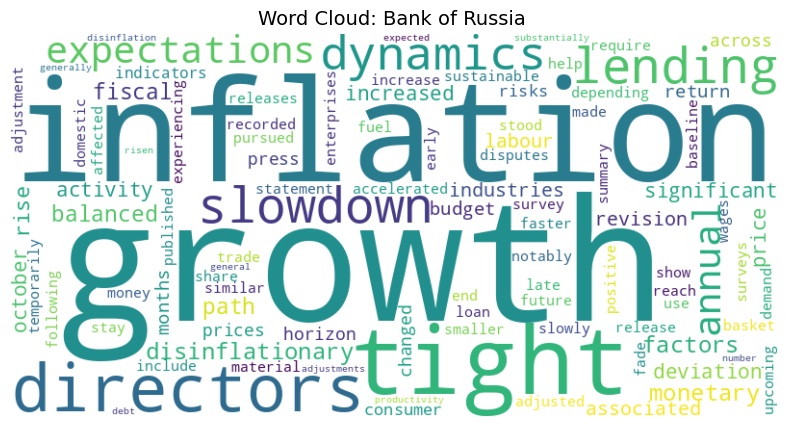

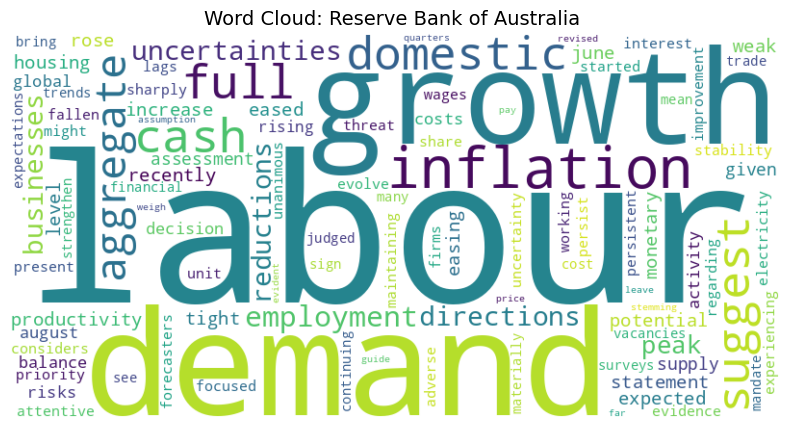

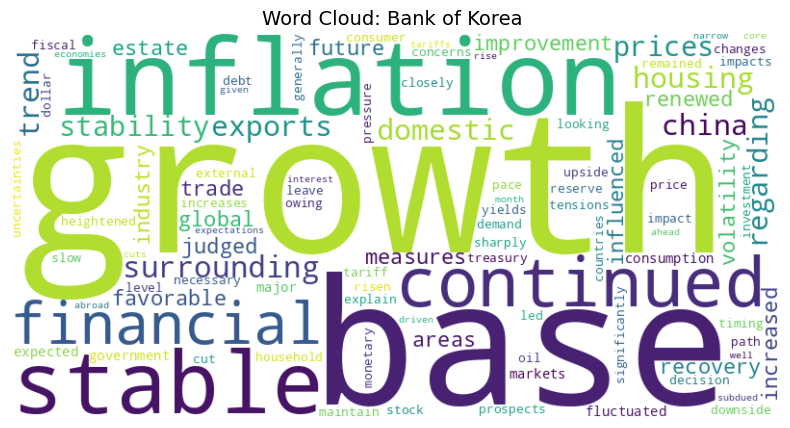

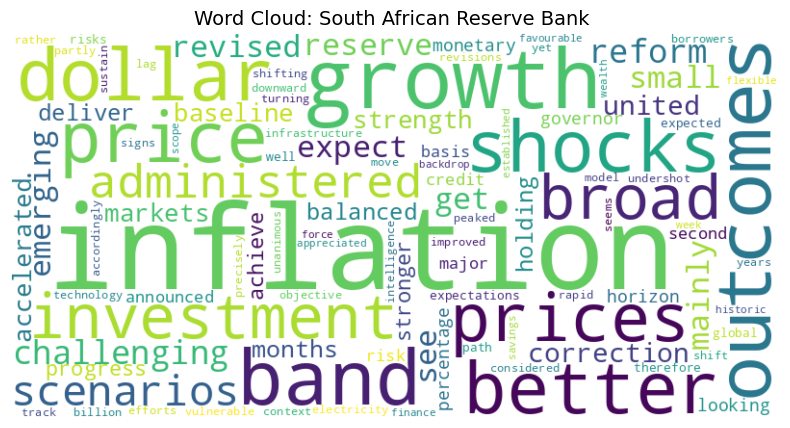

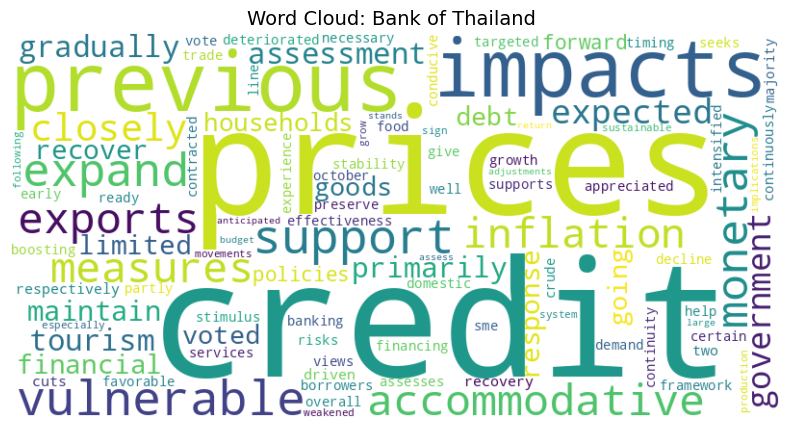

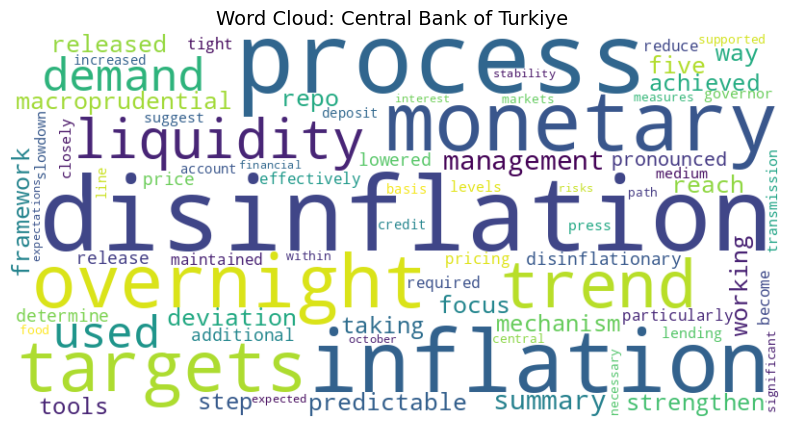

In [17]:
from wordcloud import WordCloud

for i, row in df. iterrows():
  wc_data = dict(top_tfidf_terms_for_doc(i, top_n=100))
  wc = WordCloud(width=800, height=400, background_color='white')
  wc.generate_from_frequencies(wc_data)

  plt.figure(figsize=(10,5))
  plt.imshow(wc, interpolation='bilinear')
  plt.axis('off')
  plt.title(f"Word Cloud: {df.loc[i,'central_bank']} ", fontsize=14)
  plt.show()


Comparing the TF-IDF weight of a specific term across different central bank speeches, with code adapted from Stack Overflow [[1](https://stackoverflow.com/questions/43214978/how-to-display-custom-values-on-a-bar-plot), [2](https://stackoverflow.com/questions/38830250/how-to-fill-matplotlib-bars-with-a-gradient), [3](https://stackoverflow.com/questions/67409261/histogram-with-seaborn)] and [Krisel 2025](https://github.com/rskrisel/tfidf_topic_modeling/blob/main/Intro_Text_Analysis_TFIDF_LDA_Inaugurals.ipynb) to show the central banks with the top 5 highest TF-IDF weights for a given word. I also used the Colab-embedded Gemini to modify code to show the top 5 observations (prompt: how to graph the highest tf-idf weight observations of a  word input).

As such, it is possible to investigate which banks most mention distinct concerns, such as inflation, trade, or labor market dynamics. I attempted to search for additional words, such as agriculture, agricultural, and artificial intelligence, but they were not found in the TF-IDF vocabulary.

Top 5 highest TF-IDF weights for 'inflation':


,central_bank,tfidf_score
1,Bank of England,0.450557
5,Norges Bank,0.448053
12,South African Reserve Bank,0.439917
8,Singapore Monetary Authority,0.326173
3,Reserve Bank of India,0.323983


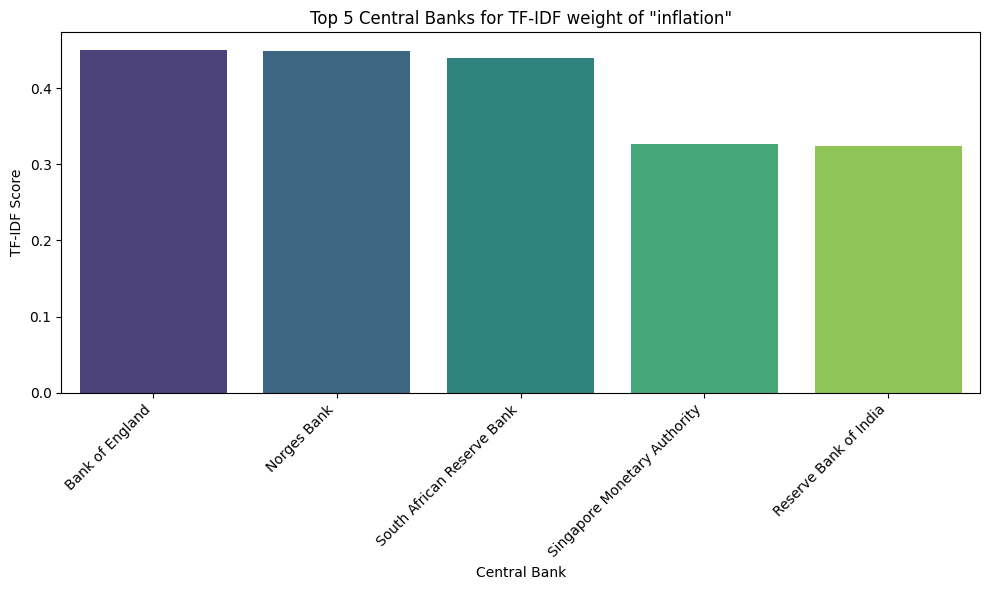

In [38]:
search_term = 'inflation'

if search_term in terms:
    term_idx = np.where(terms == search_term)[0][0]

    tfidf_scores = X_tfidf[:, term_idx].toarray().ravel()

    # Create a dataframe
    term_tfidf_df = pd.DataFrame({
        'central_bank': df['central_bank'],
        'tfidf_score': tfidf_scores
    })

    top_5_weights = term_tfidf_df.sort_values(by='tfidf_score', ascending=False).head(5)

    print(f"Top 5 highest TF-IDF weights for '{search_term}':")
    display(top_5_weights)

    # graph
    plt.figure(figsize=(10, 6))
    sns.barplot(x='central_bank', y='tfidf_score', data=top_5_weights, palette='viridis', hue = 'central_bank', legend=False)
    plt.xlabel('Central Bank')
    plt.ylabel('TF-IDF Score')
    plt.title(f'Top 5 Central Banks for TF-IDF weight of "{search_term}"')
    plt.xlabel('Central Bank')
    plt.ylabel('TF-IDF Score')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"The term '{search_term}' was not found in the vocabulary.")

Top 5 highest TF-IDF weights for 'disinflation':


,central_bank,tfidf_score
14,Central Bank of Turkiye,0.351684
1,Bank of England,0.250617
5,Norges Bank,0.044055
9,Bank of Russia,0.043995
3,Reserve Bank of India,0.000000


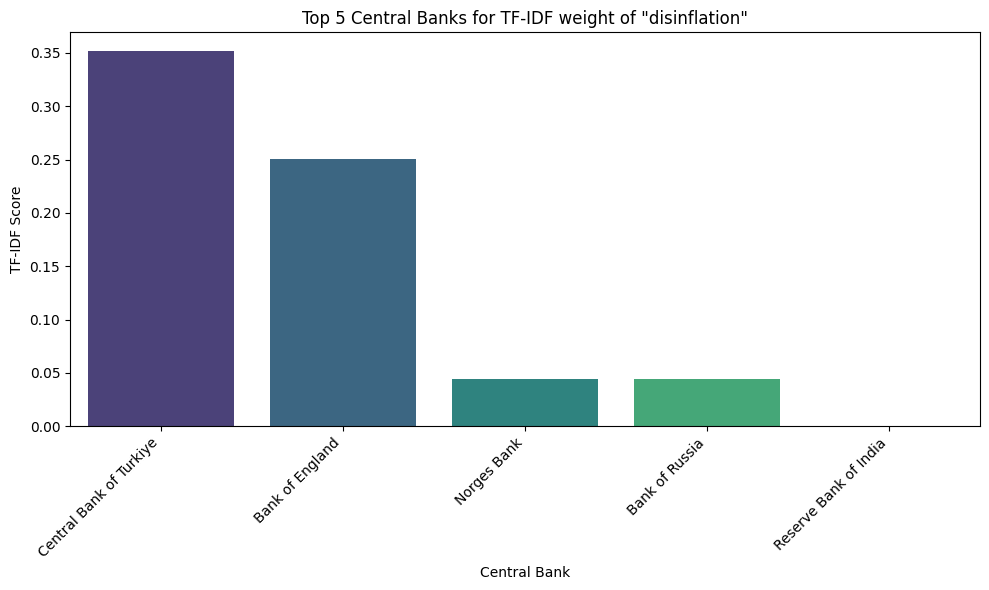

In [36]:
search_term = 'disinflation'

if search_term in terms:
    term_idx = np.where(terms == search_term)[0][0]

    tfidf_scores = X_tfidf[:, term_idx].toarray().ravel()

    # Create a dataframe
    term_tfidf_df = pd.DataFrame({
        'central_bank': df['central_bank'],
        'tfidf_score': tfidf_scores
    })

    top_5_weights = term_tfidf_df.sort_values(by='tfidf_score', ascending=False).head(5)

    print(f"Top 5 highest TF-IDF weights for '{search_term}':")
    display(top_5_weights)

    # graph
    plt.figure(figsize=(10, 6))
    sns.barplot(x='central_bank', y='tfidf_score', data=top_5_weights, palette='viridis', hue = 'central_bank', legend=False)
    plt.xlabel('Central Bank')
    plt.ylabel('TF-IDF Score')
    plt.title(f'Top 5 Central Banks for TF-IDF weight of "{search_term}"')
    plt.xlabel('Central Bank')
    plt.ylabel('TF-IDF Score')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"The term '{search_term}' was not found in the vocabulary.")

Top 5 highest TF-IDF weights for 'exports':


,central_bank,tfidf_score
7,Bank of Canada,0.252933
13,Bank of Thailand,0.149489
11,Bank of Korea,0.129097
6,Swiss National Bank,0.067236
2,European Central Bank,0.000000


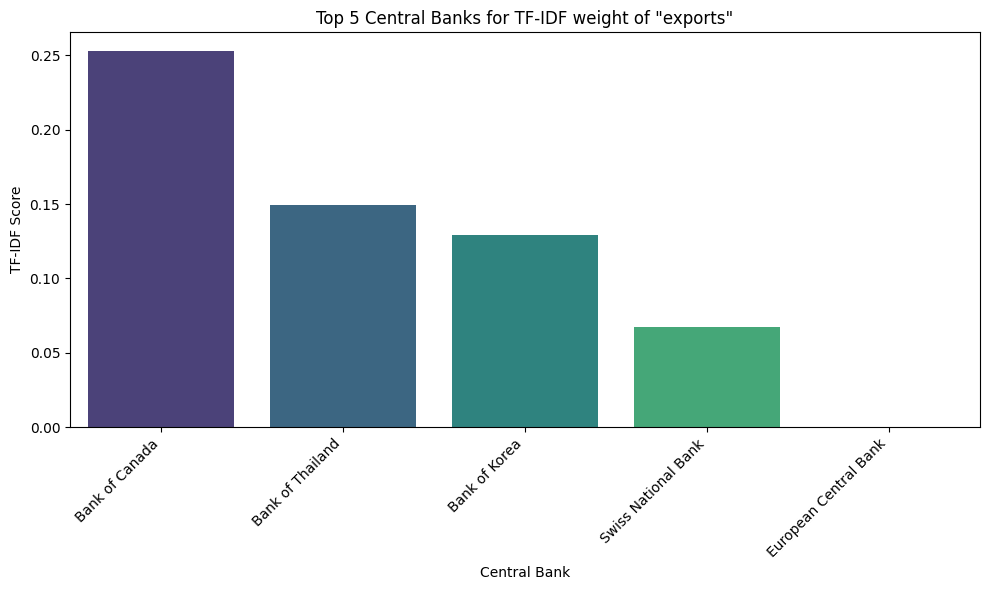

In [22]:
search_term = 'exports'

if search_term in terms:
    term_idx = np.where(terms == search_term)[0][0]

    tfidf_scores = X_tfidf[:, term_idx].toarray().ravel()

    # Create a dataframe
    term_tfidf_df = pd.DataFrame({
        'central_bank': df['central_bank'],
        'tfidf_score': tfidf_scores
    })

    top_5_weights = term_tfidf_df.sort_values(by='tfidf_score', ascending=False).head(5)

    print(f"Top 5 highest TF-IDF weights for '{search_term}':")
    display(top_5_weights)

    # graph
    plt.figure(figsize=(10, 6))
    sns.barplot(x='central_bank', y='tfidf_score', data=top_5_weights, palette='viridis', hue = 'central_bank', legend=False)
    plt.xlabel('Central Bank')
    plt.ylabel('TF-IDF Score')
    plt.title(f'Top 5 Central Banks for TF-IDF weight of "{search_term}"')
    plt.xlabel('Central Bank')
    plt.ylabel('TF-IDF Score')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"The term '{search_term}' was not found in the vocabulary.")

Top 5 highest TF-IDF weights for 'trade':


,central_bank,tfidf_score
7,Bank of Canada,0.169448
11,Bank of Korea,0.113256
6,Swiss National Bank,0.075073
8,Singapore Monetary Authority,0.062195
13,Bank of Thailand,0.055638


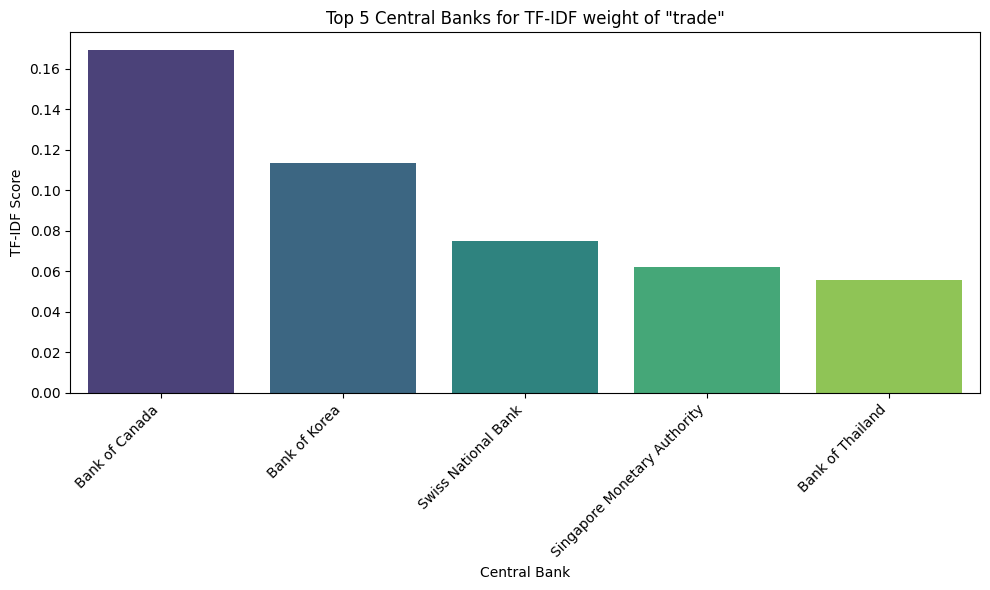

In [26]:
search_term = 'trade'

if search_term in terms:
    term_idx = np.where(terms == search_term)[0][0]

    tfidf_scores = X_tfidf[:, term_idx].toarray().ravel()

    # Create a dataframe
    term_tfidf_df = pd.DataFrame({
        'central_bank': df['central_bank'],
        'tfidf_score': tfidf_scores
    })

    top_5_weights = term_tfidf_df.sort_values(by='tfidf_score', ascending=False).head(5)

    print(f"Top 5 highest TF-IDF weights for '{search_term}':")
    display(top_5_weights)

    # graph
    plt.figure(figsize=(10, 6))
    sns.barplot(x='central_bank', y='tfidf_score', data=top_5_weights, palette='viridis', hue = 'central_bank', legend=False)
    plt.xlabel('Central Bank')
    plt.ylabel('TF-IDF Score')
    plt.title(f'Top 5 Central Banks for TF-IDF weight of "{search_term}"')
    plt.xlabel('Central Bank')
    plt.ylabel('TF-IDF Score')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"The term '{search_term}' was not found in the vocabulary.")

Top 5 highest TF-IDF weights for 'import':


,central_bank,tfidf_score
5,Norges Bank,0.054458
3,Reserve Bank of India,0.045596
0,Federal Reserve,0.000000
2,European Central Bank,0.000000
1,Bank of England,0.000000


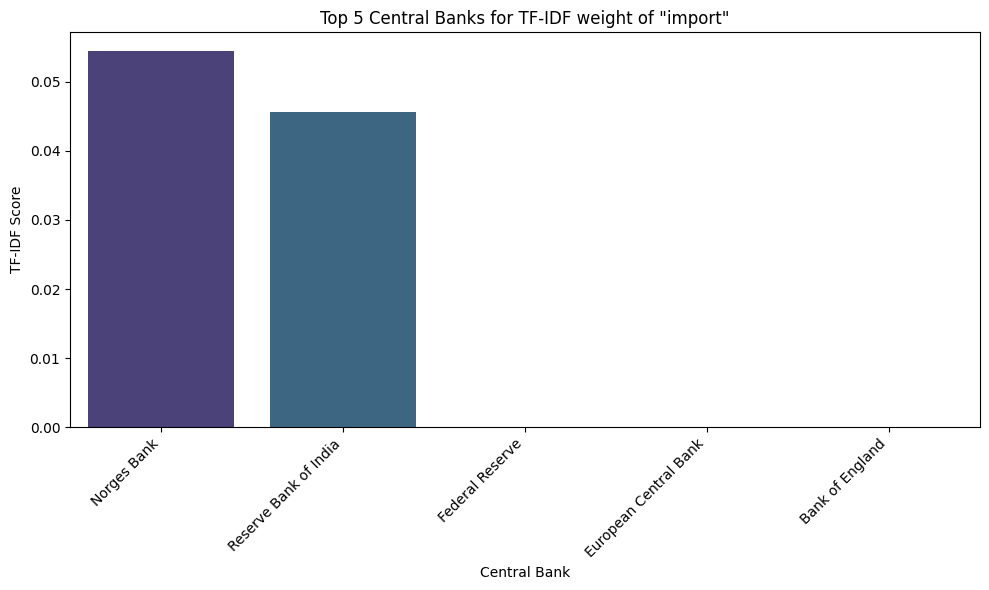

In [33]:
search_term = 'import'

if search_term in terms:
    term_idx = np.where(terms == search_term)[0][0]

    tfidf_scores = X_tfidf[:, term_idx].toarray().ravel()

    # Create a dataframe
    term_tfidf_df = pd.DataFrame({
        'central_bank': df['central_bank'],
        'tfidf_score': tfidf_scores
    })

    top_5_weights = term_tfidf_df.sort_values(by='tfidf_score', ascending=False).head(5)

    print(f"Top 5 highest TF-IDF weights for '{search_term}':")
    display(top_5_weights)

    # graph
    plt.figure(figsize=(10, 6))
    sns.barplot(x='central_bank', y='tfidf_score', data=top_5_weights, palette='viridis', hue = 'central_bank', legend=False)
    plt.xlabel('Central Bank')
    plt.ylabel('TF-IDF Score')
    plt.title(f'Top 5 Central Banks for TF-IDF weight of "{search_term}"')
    plt.xlabel('Central Bank')
    plt.ylabel('TF-IDF Score')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"The term '{search_term}' was not found in the vocabulary.")

Top 5 highest TF-IDF weights for 'technology':


,central_bank,tfidf_score
12,South African Reserve Bank,0.051145
4,Peoples Bank of China,0.040781
1,Bank of England,0.000000
2,European Central Bank,0.000000
3,Reserve Bank of India,0.000000


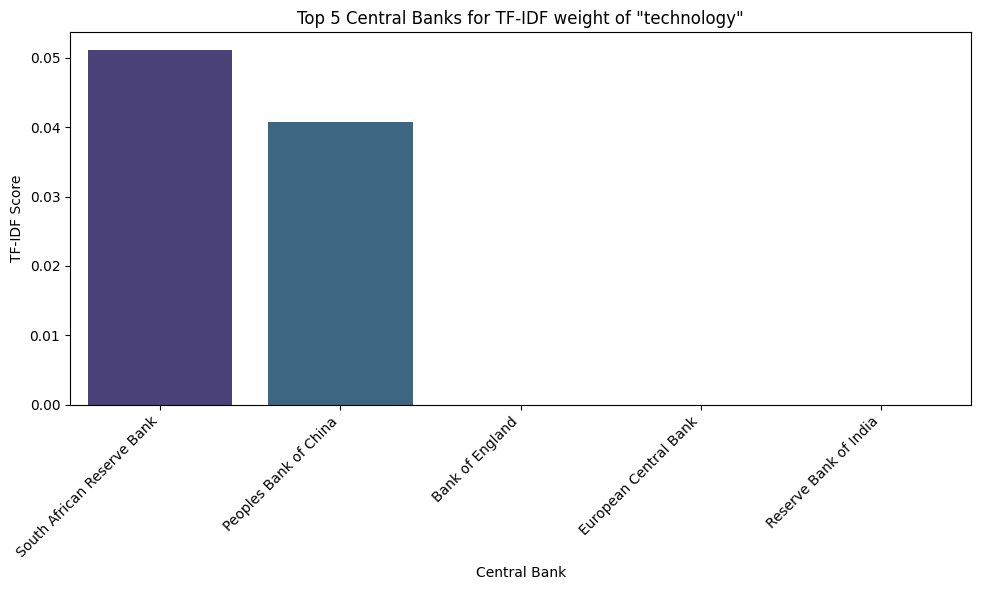

In [34]:
search_term = 'technology'

if search_term in terms:
    term_idx = np.where(terms == search_term)[0][0]

    tfidf_scores = X_tfidf[:, term_idx].toarray().ravel()

    # Create a dataframe
    term_tfidf_df = pd.DataFrame({
        'central_bank': df['central_bank'],
        'tfidf_score': tfidf_scores
    })

    top_5_weights = term_tfidf_df.sort_values(by='tfidf_score', ascending=False).head(5)

    print(f"Top 5 highest TF-IDF weights for '{search_term}':")
    display(top_5_weights)

    # graph
    plt.figure(figsize=(10, 6))
    sns.barplot(x='central_bank', y='tfidf_score', data=top_5_weights, palette='viridis', hue = 'central_bank', legend=False)
    plt.xlabel('Central Bank')
    plt.ylabel('TF-IDF Score')
    plt.title(f'Top 5 Central Banks for TF-IDF weight of "{search_term}"')
    plt.xlabel('Central Bank')
    plt.ylabel('TF-IDF Score')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"The term '{search_term}' was not found in the vocabulary.")

**Results**: comparing TF-IDF results with economic conditions in each country

*Inflation*: The central bank statements with the highest TF-IDF weights for "inflation" are the Bank of England, Norges Bank, South African Reserve Bank, Singapore Monetary Authority, and Reserve Bank of India.  For the BOE at the time of their Nov. 5 decision, inflation was softening but present, which led the MPC to keep rates unchanged. Similarly, persistent inflation in Norway led Norges Bank to maintain their policy rate in their November meeting.  For the South African Reserve Bank, inflation crept up prior to the monetary policy decision, in which they cut their policy rate. In Singapore, easing inflation in September and early October led the MAS to keep rates unchanged. In India, manageable inflation led the RBI to keep rates unchanged.

*Disinflation*: The Central Bank of Turkiye, BOE, Norges Bank, and Bank of Russia had higher TF-IDF scores for "disinflation", which is consistent with Turkiye being in a period of disinflation after a prolonged period of high inflation, softening inflation in England, and slowing inflation in Russia, while Norway's persistent inflation is not likely to result in disinflation in the near term.

*Exports*: The Bank of Canada, Bank of Thailand, Bank of Korea, and Swiss National Bank had the highest TF-IDF scores for "exports", which is consistent with a significant portion—32.5%, 70.1%, 44%, and 72.2%, respectively—of GDP attributable of exports of goods and services in 2024. As such, the frequent presence of the word "exports" in the monetary policy statements of each country's central bank is consistent with the unique relevant economic conditions of the country.

*Trade*: Further, the Bank of Canada, Bank of Korea, Swiss National Bank, Singapore Monetary Authority, and Bank of Thailand had the highest TF-IDF scores for the term "trade", which is consistent with the aforementioned importance of trade and exports within their national economies.  

*Imports*: Norges Bank and the Reserve Bank of India had the highest TF-IDF scores for the term "imports", which is congruent with imports totaling 33.7% and 23,5%, respectively, as a share of GDP in 2024.

*Technology*: The South African Reserve Bank and People's Bank of China had the highest TF-IDF scores for "technology" in their monetary policy statements, which is consistent with estimates of the digital economy accounting for 15-20% of South African GDP in 2025, with the tech sector expected to continue growing, as well as the digital economy accounting for 42.8% of Chinese GDP and a booming tech sector (estimated to be worth around 19% of GDP in 2026).

**Discussion**

While some search terms, such as trade, exports, imports, technology, and disinflation (to a certain extent), resulted in fruitful analysis that provided insight into the particular economic conditions of a given country and the considerations of its central bank in setting monetary policy, other search terms, such as inflation and labor, did not yield conclusive results. This is likely due to the fact that inflation and labor market dynamics are the most common primary focuses of central banks around the world, so the simple presence of the terms did not highlight unique considerations or conditions. Further, as previously mentioned, the nature of TF-IDF text analysis removes the context surrounding a given word; a monetary policy statement having a high TF-IDF score for a ubiqutous word such as inflation does not reveal how the concept or theme influenced decision-making or how the economic phenomenon manifests in a particular country.

**Limitations and questions for future research**

While this study examined 15 central bank statements, it is a relatively small sample size and a larger sample size would likely shed additional light on the relationship between central bank statements and national economic challenges. Incorporating different text materials, such as longer reports, might also increase the size of the corpus analyzed and provide more insight into the details of banks’ foremost concerns. Further, examining the monetary policy statements of a central bank (or multiple) over time would illuminate how the primary issues considered by a central bank evolved over a given period of time.